<a href="https://colab.research.google.com/github/VivekOPest/gaia-symbolic-regression/blob/main/02_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2 – Dataset Analysis

This notebook evaluates the processed Gaia dataset before symbolic regression.

Objectives

- Inspect the distributions of each variable.
- Detect potential outliers.
- Examine relationships between the predictor variables and observed flux.
- Assess overall data quality.

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv("gaia_features.csv")

print(df.shape)

df.head()

(20000, 4)


,temperature_K,distance_m,radius_m,flux_proxy
0,4896.8936,3.306717e+19,5.826488e+08,6783.598485
1,4397.8647,7.177110e+18,4.932513e+08,38620.291417
2,5307.8760,3.872305e+19,5.529424e+08,9817.506707
3,5952.5596,2.277680e+19,1.655418e+09,262440.355661
4,4525.4976,2.523367e+19,5.972584e+08,4903.220496


In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_K,20000.0,5.158960e+03,1.145363e+03,2.725162e+03,4.469922e+03,5.152145e+03,5.772950e+03,3.499937e+04
distance_m,20000.0,3.573051e+19,2.309377e+19,1.128846e+18,1.917680e+19,3.152003e+19,4.604989e+19,1.935316e+20
radius_m,20000.0,1.136959e+09,4.443260e+09,1.095032e+08,4.661190e+08,6.020240e+08,8.972095e+08,4.230188e+11
flux_proxy,20000.0,7.066669e+04,9.033751e+05,4.731252e+02,4.311627e+03,1.042746e+04,2.645813e+04,5.718408e+07


In [35]:
labels = {
    "temperature_K": "Temperature (K)",
    "distance_m": "Distance (m)",
    "radius_m": "Radius (m)",
    "flux_proxy": "Flux Proxy (e⁻ s⁻¹)"
}

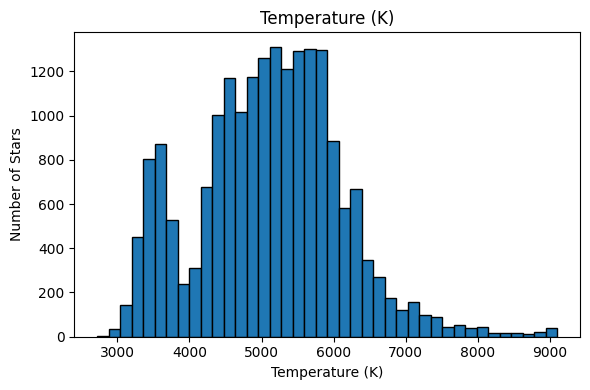

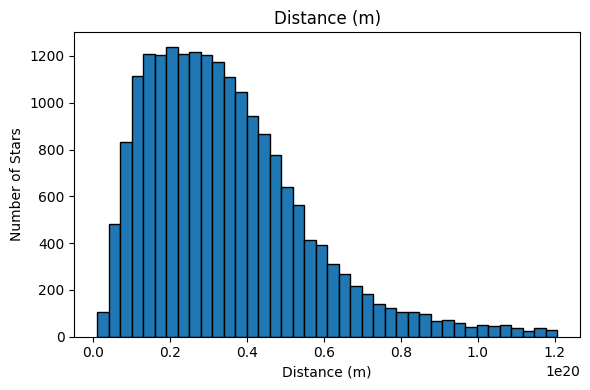

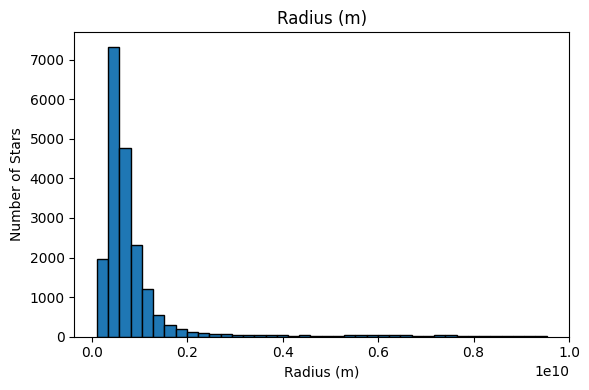

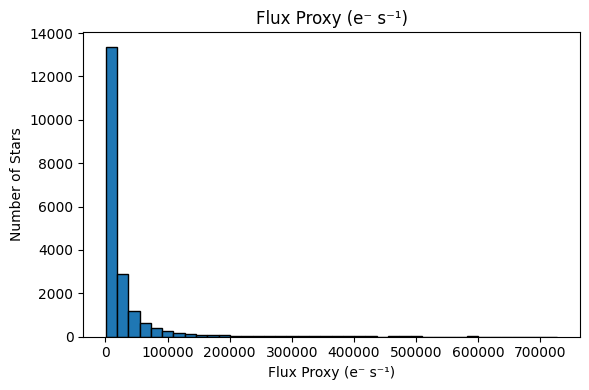

In [36]:
columns = list(labels.keys())

for col in columns:

    plt.figure(figsize=(6,4))

    upper = df[col].quantile(0.99)

    plt.hist(
        df[df[col] <= upper][col],
        bins=40,
        edgecolor="black"
    )

    plt.title(labels[col])

    plt.xlabel(labels[col])

    plt.ylabel("Number of Stars")

    plt.tight_layout()

    plt.show()

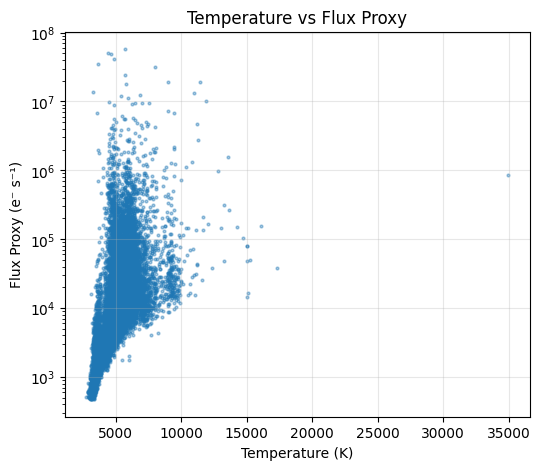

In [37]:
plt.figure(figsize=(6,5))

plt.scatter(
    df["temperature_K"],
    df["flux_proxy"],
    s=4,
    alpha=0.4
)

plt.yscale("log")

plt.xlabel("Temperature (K)")

plt.ylabel("Flux Proxy (e⁻ s⁻¹)")

plt.title("Temperature vs Flux Proxy")

plt.grid(alpha=0.3)

plt.show()

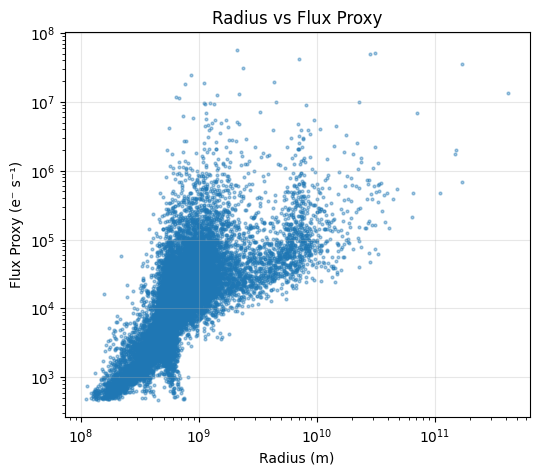

In [38]:
plt.figure(figsize=(6,5))

plt.scatter(
    df["radius_m"],
    df["flux_proxy"],
    s=4,
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Radius (m)")

plt.ylabel("Flux Proxy (e⁻ s⁻¹)")

plt.title("Radius vs Flux Proxy")

plt.grid(alpha=0.3)

plt.show()

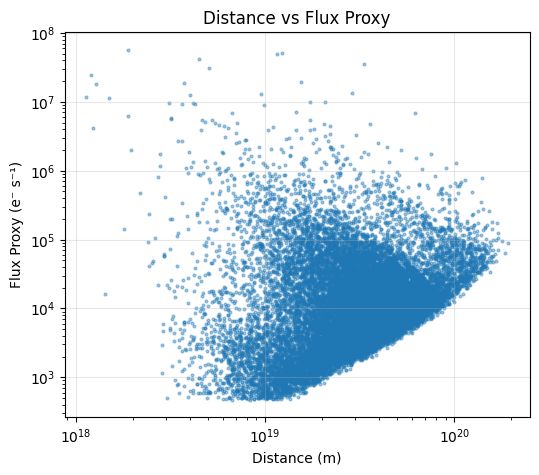

In [39]:
plt.figure(figsize=(6,5))

plt.scatter(
    df["distance_m"],
    df["flux_proxy"],
    s=4,
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Distance (m)")

plt.ylabel("Flux Proxy (e⁻ s⁻¹)")

plt.title("Distance vs Flux Proxy")

plt.grid(alpha=0.3)

plt.show()

In [40]:
corr = df.corr(numeric_only=True)

corr

,temperature_K,distance_m,radius_m,flux_proxy
temperature_K,1.000000,0.507003,0.026802,0.055333
distance_m,0.507003,1.000000,0.253284,-0.042497
radius_m,0.026802,0.253284,1.000000,0.233001
flux_proxy,0.055333,-0.042497,0.233001,1.000000


In [41]:
corr["flux_proxy"].sort_values()

,flux_proxy
distance_m,-0.042497
temperature_K,0.055333
radius_m,0.233001
flux_proxy,1.000000


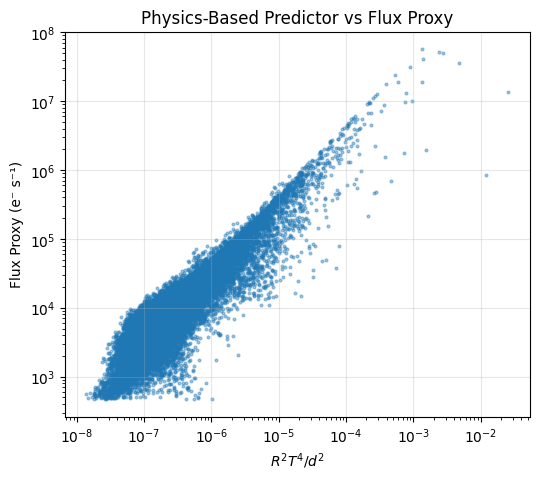

In [42]:
physics_predictor = (
    df["radius_m"]**2 *
    df["temperature_K"]**4 /
    df["distance_m"]**2
)

plt.figure(figsize=(6,5))

plt.scatter(
    physics_predictor,
    df["flux_proxy"],
    s=4,
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$R^2T^4/d^2$")
plt.ylabel("Flux Proxy (e⁻ s⁻¹)")
plt.title("Physics-Based Predictor vs Flux Proxy")

plt.grid(alpha=0.3)

plt.show()